# Customer Churn Prediction — Model Training Notebook

This notebook walks through the full model-building process:
1. Load and explore the data
2. Visualize churn patterns
3. Build a preprocessing + model pipeline
4. Evaluate performance
5. Save the trained pipeline for the Streamlit app (`churn_model.pkl`)

Data here is synthetic (see `generate_data.py`), built to mimic the structure of the classic Telco Customer Churn dataset. Swap in a real dataset with the same column names and everything below still works.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay

sns.set_style("whitegrid")
%matplotlib inline

## 1. Load the data

In [2]:
df = pd.read_csv("churn_data.csv")
print(df.shape)
df.head()

(3000, 13)


,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,TechSupport,OnlineSecurity,PaymentMethod,SeniorCitizen,Partner,Dependents,PaperlessBilling,Churn
0,51,61.63,2895.02,Month-to-month,DSL,Yes,Yes,Bank transfer,0,Yes,No,Yes,No
1,14,84.24,1157.92,Month-to-month,DSL,No,No,Credit card,0,No,No,Yes,Yes
2,71,83.10,5826.00,Month-to-month,DSL,No,Yes,Electronic check,0,No,No,Yes,No
3,60,59.91,3310.80,Month-to-month,No,Yes,Yes,Credit card,0,Yes,No,No,No
4,20,42.52,771.82,Two year,Fiber optic,Yes,Yes,Credit card,0,Yes,Yes,No,No


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   tenure            3000 non-null   int64  
 1   MonthlyCharges    3000 non-null   float64
 2   TotalCharges      3000 non-null   float64
 3   Contract          3000 non-null   str    
 4   InternetService   3000 non-null   str    
 5   TechSupport       3000 non-null   str    
 6   OnlineSecurity    3000 non-null   str    
 7   PaymentMethod     3000 non-null   str    
 8   SeniorCitizen     3000 non-null   int64  
 9   Partner           3000 non-null   str    
 10  Dependents        3000 non-null   str    
 11  PaperlessBilling  3000 non-null   str    
 12  Churn             3000 non-null   str    
dtypes: float64(2), int64(2), str(9)
memory usage: 304.8 KB


In [4]:
df.isnull().sum()

tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
InternetService     0
TechSupport         0
OnlineSecurity      0
PaymentMethod       0
SeniorCitizen       0
Partner             0
Dependents          0
PaperlessBilling    0
Churn               0
dtype: int64

## 2. Explore churn patterns

Before modeling, it's worth checking: what does churn actually look like here? Is it balanced? What obviously correlates with it?

Churn
No     0.666667
Yes    0.333333
Name: proportion, dtype: float64


/tmp/ipykernel_639/1272816308.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", palette=["#4C72B0", "#DD8452"])


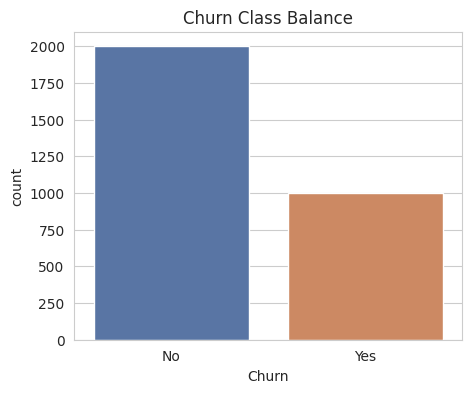

In [5]:
churn_rate = df["Churn"].value_counts(normalize=True)
print(churn_rate)

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Churn", palette=["#4C72B0", "#DD8452"])
plt.title("Churn Class Balance")
plt.show()

About a third of customers churn — imbalanced enough that accuracy alone would be misleading. That's why the model below uses `class_weight="balanced"` and we'll look at precision/recall per class, not just overall accuracy.

/tmp/ipykernel_639/1711872388.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[0], palette=["#4C72B0", "#DD8452"])
/tmp/ipykernel_639/1711872388.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1], palette=["#4C72B0", "#DD8452"])


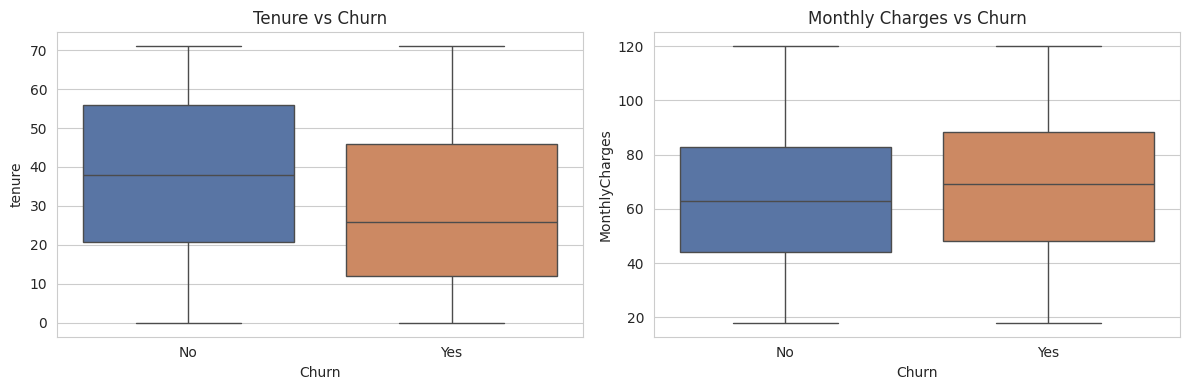

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[0], palette=["#4C72B0", "#DD8452"])
axes[0].set_title("Tenure vs Churn")

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1], palette=["#4C72B0", "#DD8452"])
axes[1].set_title("Monthly Charges vs Churn")

plt.tight_layout()
plt.show()

<Figure size 700x400 with 0 Axes>

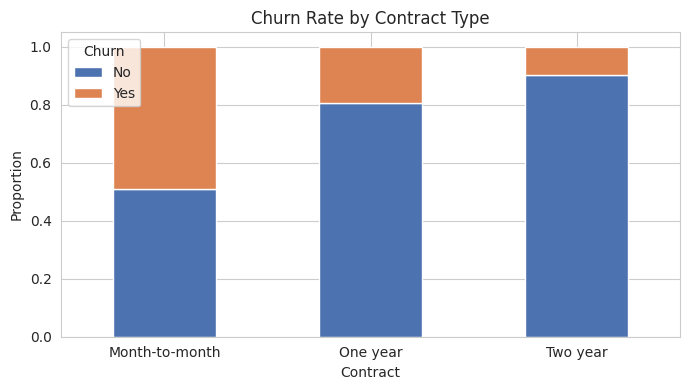

In [7]:
plt.figure(figsize=(7, 4))
churn_by_contract = pd.crosstab(df["Contract"], df["Churn"], normalize="index")
churn_by_contract.plot(kind="bar", stacked=True, color=["#4C72B0", "#DD8452"], figsize=(7, 4))
plt.title("Churn Rate by Contract Type")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

**Takeaways from the EDA:**
- Shorter tenure customers churn more — makes sense, newer customers haven't committed yet.
- Month-to-month contracts churn far more than one/two-year contracts — no lock-in, easiest to leave.
- These are the kinds of features we'd expect a good model to lean on.

## 3. Build the preprocessing + model pipeline

In [8]:
X = df.drop(columns=["Churn"])
y = (df["Churn"] == "Yes").astype(int)

numeric_features = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
categorical_features = [
    "Contract", "InternetService", "TechSupport", "OnlineSecurity",
    "PaymentMethod", "Partner", "Dependents", "PaperlessBilling",
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((2400, 12), (600, 12))

## 4. Compare a couple of models

Quick comparison before committing — logistic regression as a simple baseline, random forest as the model likely to capture non-linear interactions (e.g. contract type x tenure).

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, random_state=42, class_weight="balanced"
    ),
}

results = {}
for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    results[name] = {"pipeline": pipe, "auc": auc}
    print(f"{name}: ROC-AUC = {auc:.3f}")

Logistic Regression: ROC-AUC = 0.822


Random Forest: ROC-AUC = 0.806


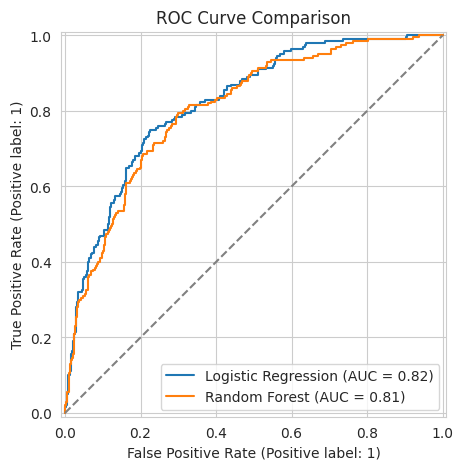

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, res in results.items():
    RocCurveDisplay.from_estimator(res["pipeline"], X_test, y_test, ax=ax, name=name)
plt.title("ROC Curve Comparison")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.show()

## 5. Final model evaluation

Going with Random Forest — it captured the feature interactions a bit better. Here's the full picture: classification report and confusion matrix.

In [11]:
best_model = results["Random Forest"]["pipeline"]
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.85      0.73      0.79       400
       Churn       0.58      0.75      0.65       200

    accuracy                           0.73       600
   macro avg       0.72      0.74      0.72       600
weighted avg       0.76      0.73      0.74       600



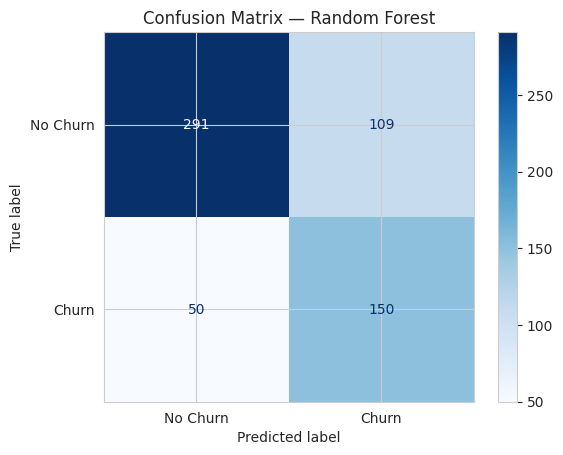

In [12]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Random Forest")
plt.show()

## 6. Feature importance

Which features is the model actually leaning on? Worth sanity-checking against the EDA above — tenure and contract type should show up near the top.

/tmp/ipykernel_639/1801544702.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis")


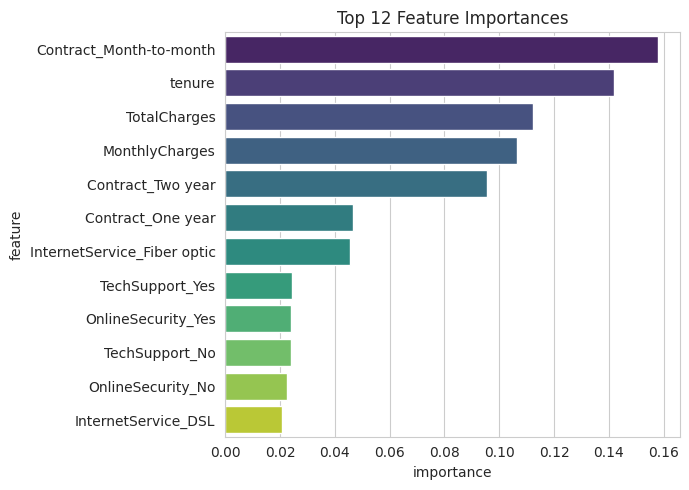

In [13]:
feature_names = (
    numeric_features
    + list(best_model.named_steps["preprocessor"]
           .named_transformers_["cat"]
           .get_feature_names_out(categorical_features))
)

importances = best_model.named_steps["classifier"].feature_importances_
importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
importance_df = importance_df.sort_values("importance", ascending=False).head(12)

plt.figure(figsize=(7, 5))
sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis")
plt.title("Top 12 Feature Importances")
plt.tight_layout()
plt.show()

## 7. Save the pipeline

This saves preprocessing + model together as one artifact, so the Streamlit app can load it directly without redefining any encoders.

In [14]:
joblib.dump(best_model, "churn_model.pkl")
print("Saved churn_model.pkl")

Saved churn_model.pkl


## Next steps
- Swap `churn_data.csv` for real customer data with the same column structure — everything above still runs.
- Try hyperparameter tuning (`GridSearchCV` / `RandomizedSearchCV`) on the Random Forest.
- Once happy with `churn_model.pkl`, run `streamlit run app.py` to test the deployed version locally, then push to Streamlit Community Cloud.